# Documentación Completa: Sistema de Dos Masas-Resortes 3D con Análisis en Tiempo Real

## 1. FUNDAMENTOS TEÓRICOS

### 1.1 Planteamiento del Problema

El sistema consiste en dos masas conectadas en serie mediante resortes ideales, suspendidas desde un punto fijo (techo).

**Configuración geométrica:**

$$\text{Techo} \xrightarrow{k_1, L_1} m_1 \xrightarrow{k_2, L_2} m_2$$

**Variables de estado:**
- $y_1(t)$: Posición vertical de $m_1$ (positivo hacia abajo desde el techo)
- $y_2(t)$: Posición vertical de $m_2$
- $x_1(t), z_1(t)$: Desplazamientos horizontales de $m_1$
- $x_2(t), z_2(t)$: Desplazamientos horizontales de $m_2$

### 1.2 Análisis de Equilibrio Estático

**Diagrama de cuerpo libre - Masa $m_2$ (inferior):**

Fuerzas verticales en equilibrio:
$$\sum F_y = 0 \Rightarrow T_2 - m_2 g = 0$$

Por la ley de Hooke:
$$T_2 = k_2 \cdot \Delta L_2$$

Por lo tanto:
$$\Delta L_2 = \frac{m_2 g}{k_2}$$

**Diagrama de cuerpo libre - Masa $m_1$ (superior):**

$$\sum F_y = 0 \Rightarrow T_1 - T_2 - m_1 g = 0$$

$$T_1 = (m_1 + m_2)g$$

$$\Delta L_1 = \frac{(m_1 + m_2)g}{k_1}$$

**Posiciones de equilibrio:**

$$y_{1,eq} = h_{techo} - (L_1 + \Delta L_1)$$

$$y_{2,eq} = y_{1,eq} - (L_2 + \Delta L_2)$$

Donde $h_{techo}$ es la altura del techo respecto al origen.

---

## 2. MATRICES DEL SISTEMA

### 2.1 Matriz de Masas

$$\mathbf{M} = \begin{pmatrix} m_1 & 0 \\ 0 & m_2 \end{pmatrix}$$

### 2.2 Matriz de Rigidez

Para movimiento vertical, las ecuaciones acopladas son:

$$m_1 \ddot{u}_1 = -(k_1 + k_2)u_1 + k_2 u_2$$
$$m_2 \ddot{u}_2 = k_2 u_1 - k_2 u_2$$

Donde $u_i = y_i - y_{i,eq}$ son los desplazamientos desde el equilibrio.

En forma matricial:
$$\mathbf{M}\ddot{\mathbf{u}} = \mathbf{K}\mathbf{u}$$

$$\mathbf{K} = \begin{pmatrix} -(k_1 + k_2) & k_2 \\ k_2 & -k_2 \end{pmatrix}$$

---

## 3. PROBLEMA DE EIGENVALORES

### 3.1 Formulación

Buscamos soluciones de la forma $\mathbf{u}(t) = \mathbf{v}e^{i\omega t}$, lo que lleva a:

$$(\mathbf{K} - \omega^2 \mathbf{M})\mathbf{v} = \mathbf{0}$$

Multiplicando por $\mathbf{M}^{-1}$:
$$\mathbf{M}^{-1}\mathbf{K}\mathbf{v} = -\omega^2 \mathbf{v}$$

Definiendo $\lambda = -\omega^2$ (eigenvalor), resolvemos:
$$\det(\mathbf{M}^{-1}\mathbf{K} - \lambda\mathbf{I}) = 0$$

### 3.2 Cálculo de Eigenvalores

La matriz $\mathbf{A} = \mathbf{M}^{-1}\mathbf{K}$ tiene elementos:
$$a = \frac{-(k_1+k_2)}{m_1}, \quad b = \frac{k_2}{m_1}$$
$$c = \frac{k_2}{m_2}, \quad d = \frac{-k_2}{m_2}$$

El polinomio característico es:
$$\lambda^2 - (a+d)\lambda + (ad-bc) = 0$$

Soluciones:
$$\lambda_{1,2} = \frac{\text{traza} \pm \sqrt{\text{traza}^2 - 4\det}}{2}$$

### 3.3 Frecuencias Naturales

$$\omega_i = \sqrt{-\lambda_i} \quad (\text{para } \lambda_i < 0)$$

$$f_i = \frac{\omega_i}{2\pi}, \quad T_i = \frac{1}{f_i}$$

### 3.4 Eigenvectores (Modos Normales)

Para cada $\lambda_i$, resolvemos $(\mathbf{A} - \lambda_i\mathbf{I})\mathbf{v}_i = \mathbf{0}$:

**Modo 1 (baja frecuencia):** Las masas se mueven en fase (misma dirección)

**Modo 2 (alta frecuencia):** Las masas se mueven en contrafase (direcciones opuestas)

---

## 4. SOLUCIÓN GENERAL

### 4.1 Combinación Lineal de Modos

$$\mathbf{u}(t) = A_1\mathbf{v}_1\cos(\omega_1 t + \phi_1) + A_2\mathbf{v}_2\cos(\omega_2 t + \phi_2)$$

### 4.2 Determinación de Constantes

Por condiciones iniciales $\mathbf{u}(0) = \mathbf{u}_0$, $\dot{\mathbf{u}}(0) = \mathbf{v}_0$:

$$\begin{pmatrix} A_1\cos\phi_1 \\ A_2\cos\phi_2 \end{pmatrix} = \mathbf{V}^{-1}\mathbf{u}_0$$

Donde $\mathbf{V} = [\mathbf{v}_1 \quad \mathbf{v}_2]$ es la matriz modal.

---

## 5. DINÁMICA EN TIEMPO REAL (SIMULACIÓN)

### 5.1 Fuerzas en los Resortes

Para un resorte entre puntos $\mathbf{p}_1$ y $\mathbf{p}_2$:

**Vector de dirección:**
$$\vec{d} = \mathbf{p}_2 - \mathbf{p}_1 = (x_2-x_1, y_2-y_1, z_2-z_1)$$

**Longitud actual:**
$$L = \|\vec{d}\| = \sqrt{d_x^2 + d_y^2 + d_z^2}$$

**Extensión:**
$$\Delta L = L - L_0$$

**Vector unitario:**
$$\hat{u} = \frac{\vec{d}}{L}$$

**Tensión (escalar):**
$$T = k \cdot \Delta L$$

**Fuerza sobre la masa inferior ($\mathbf{p}_2$):**
$$\vec{F}_2 = -T \cdot \hat{u}$$

**Fuerza sobre la masa superior ($\mathbf{p}_1$):**
$$\vec{F}_1 = T \cdot \hat{u}$$

### 5.2 Fuerzas Tangenciales (Flexión)

Para modelar la rigidez a la flexión:
$$F_{tang,x} = -k_t \cdot d_x$$
$$F_{tang,z} = -k_t \cdot d_z$$

Estas fuerzas actúan perpendicularmente al eje del resorte, restaurando la verticalidad.

### 5.3 Ecuaciones de Movimiento Completas

**Para $m_1$:**
$$m_1\ddot{\mathbf{r}}_1 = \vec{F}_{resorte1} + \vec{F}_{resorte2} + m_1\vec{g}$$

**Para $m_2$:**
$$m_2\ddot{\mathbf{r}}_2 = \vec{F}_{resorte2} + m_2\vec{g}$$

Donde $\vec{g} = (0, -g, 0)$ (gravedad hacia abajo).

### 5.4 Integración Numérica (Método de Euler)

**Pseudocódigo:**
PARA cada paso de tiempo dt:

# Calcular fuerzas
F1, F_techo = CalcularFuerzaResorte(techo, pos1, L1, k1, kt1)<br>
F2_m1, F2_m2 = CalcularFuerzaResorte(pos1, pos2, L2, k2, kt2)<br>

# Sumar fuerzas sobre cada masa
F_total_1 = F1 + F2_m1<br>
F_total_2 = F2_m2<br>

# Agregar gravedad
F_total_1.y -= m1 * g<br>
F_total_2.y -= m2 * g<br>

# Aceleraciones
a1 = F_total_1 / m1 <br>
a2 = F_total_2 / m2 <br>

# Limitar aceleraciones
a1 = clamp(a1, -amax, amax) <br>
a2 = clamp(a2, -amax, amax) <br>

# Actualizar velocidades (Euler)
v1 = v1 + a1 * dt <br>
v2 = v2 + a2 * dt <br>

# Amortiguamiento
v1 = v1 * damping  <br>
v2 = v2 * damping  <br> 

# Limitar velocidades
v1 = clamp(v1, -vmax, vmax)<br>
v2 = clamp(v2, -vmax, vmax)<br>

# Actualizar posiciones
pos1 = pos1 + v1 * dt<br>
pos2 = pos2 + v2 * dt<br>

# Restricciones físicas
SI distancia(pos1, pos2) < L2 * 0.3:<br>
&nbsp;&nbsp;&nbsp;&nbsp;Reposicionar(pos2, direccion desde pos1, L2 * 0.3)<br>

SI pos2.y < suelo:<br>
&nbsp;&nbsp;&nbsp;&nbsp;pos2.y = suelo<br>
&nbsp;&nbsp;&nbsp;&nbsp;v2.y = abs(v2.y) * coef_restitucion<br>

### 5.5 Detección de Colisiones y Restricciones

**Colisión m2 con m1:**
$$d_{12} = \|\mathbf{r}_2 - \mathbf{r}_1\|$$
$$\text{SI } d_{12} < L_{2,\min}: \quad \mathbf{r}_2 = \mathbf{r}_1 + L_{2,\min} \cdot \hat{d}_{12}$$

**Colisión con el suelo:**
$$\text{SI } y_2 < y_{suelo}: \quad y_2 = y_{suelo}, \quad v_{2,y} = |v_{2,y}| \cdot e$$

Donde $e$ es el coeficiente de restitución ($0 \leq e \leq 1$).

---

## 6. INTERACCIÓN CON EL USUARIO (ARRASTRE)

### 6.1 Proyección de Pantalla a Espacio 3D

**Pseudocódigo:**

FUNCION ArrastrarMasa():<br>
&nbsp;&nbsp;&nbsp;&nbsp;mouse_pos = ObtenerPosicionMouse()<br>
&nbsp;&nbsp;&nbsp;&nbsp;rayo = GetMouseRay(mouse_pos, camara)<br>
# Vector desde origen del rayo a la masa
&nbsp;&nbsp;&nbsp;&nbsp;a_masa = pos_masa - rayo.origen

# Proyeccion escalar sobre direccion del rayo
&nbsp;&nbsp;&nbsp;&nbsp;t = ProductoPunto(a_masa, rayo.direccion)

# Punto en el rayo mas cercano a la masa
&nbsp;&nbsp;&nbsp;&nbsp;punto_3d = rayo.origen + t * rayo.direccion

# Limitar distancia desde el techo (esfera)
&nbsp;&nbsp;&nbsp;&nbsp;desde_techo = punto_3d - pos_techo
&nbsp;&nbsp;&nbsp;&nbsp;dist = Norma(desde_techo)

&nbsp;&nbsp;&nbsp;&nbsp;SI dist > dist_max:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;punto_3d = pos_techo + desde_techo * (dist_max / dist)

&nbsp;&nbsp;&nbsp;&nbsp;SI dist < dist_min:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;punto_3d = pos_techo + desde_techo * (dist_min / dist)

# Limitar altura minima
&nbsp;&nbsp;&nbsp;&nbsp;SI punto_3d.y < suelo:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;punto_3d.y = suelo<br>

pos_masa = punto_3d<br>
velocidad_masa = (0, 0, 0)  # Resetear velocidad al arrastrar


### 6.2 Cambio de Modo (Arrastre a Física)

Al soltar el botón del mouse:
1. Se desactiva el modo arrastre
2. Se activa la integración numérica
3. Las velocidades iniciales son cero (o se conservan si hay "lanzamiento")
4. El sistema evoluciona según las fuerzas de resorte y gravedad

---

## 7. VISUALIZACIÓN

### 7.1 Dibujo del Resorte (Espiral 3D)

**Pseudocódigo:**

FUNCION DibujarResorte(p1, p2, radio, n_espiras, color):<br>
&nbsp;&nbsp;&nbsp;&nbsp;d = p2 - p1
&nbsp;&nbsp;&nbsp;&nbsp;L = Norma(d)
&nbsp;&nbsp;&nbsp;&nbsp;dir = d / L

# Vectores perpendiculares
&nbsp;&nbsp;&nbsp;&nbsp;arbitrario = (abs(dir.y) < 0.9) ? (0,1,0) : (1,0,0)<br>
&nbsp;&nbsp;&nbsp;&nbsp;u = Normalizar(ProductoCruz(arbitrario, dir))<br>
&nbsp;&nbsp;&nbsp;&nbsp;v = ProductoCruz(dir, u)<br>

&nbsp;&nbsp;&nbsp;&nbsp;PARA i DESDE 0 HASTA n_segmentos:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;t = i / n_segmentos<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;angulo = t * n_espiras * 2 * PI<br>
    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;punto_linea = p1 + d * t<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;r_radio = radio * sin(PI * t)  # Radio variable<br>
    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;punto_espiral = punto_linea + r_radio * (u * cos(angulo) + v * sin(angulo))<br>
    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;SI i > 0:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;DibujarLinea(punto_anterior, punto_espiral, color)<br>
    
&nbsp;&nbsp;&nbsp;&nbsp;punto_anterior = punto_espiral<br>


### 7.2 Sistema de Partículas (Rastro)

Se mantiene un buffer circular de posiciones anteriores:<br>

buffer_rastro[longitud_maxima]<br>
buffer_rastro.agregar(posicion_actual)<br>
SI buffer_rastro.lleno:<br>
&nbsp;&nbsp;&nbsp;&nbsp;buffer_rastro.eliminar_primero()<br>


---

## 8. ARCHIVOS DE SALIDA

### 8.1 Estructura de Archivos Generados

| Archivo | Contenido | Formato |
|---------|-----------|---------|
| `calculo_completo_sistema.txt` | Análisis teórico detallado | Texto plano con ecuaciones |
| `trayectorias_analiticas.txt` | $t, y_1(t), y_2(t)$ | TSV (Tab-Separated Values) |
| `eigenvalores_vectores.csv` | $\lambda_i, \omega_i, f_i, \mathbf{v}_i$ | CSV |
| `fuerzas_dinamicas.txt` | $t, F_{1y}, F_{2y}, \Delta L_1, \Delta L_2$ | TSV (tiempo real) |

### 8.2 Formato de Registro de Fuerzas

Cada fila representa un instante de la simulación:
$$t_i \quad F_{1y}(t_i) \quad F_{2y}(t_i) \quad \Delta L_1(t_i) \quad \Delta L_2(t_i)$$

Permite verificar que:
$$F_{1y} \approx k_1 \cdot \Delta L_1 \quad \text{(Ley de Hooke)}$$

---

## 9. PARÁMETROS NUMÉRICOS Y ESTABILIDAD

### 9.1 Condiciones para Estabilidad

**Paso de tiempo:**
$$\Delta t \ll \frac{1}{\omega_{max}} = \frac{1}{\max(\omega_1, \omega_2)}$$

Tipicamente: $\Delta t \approx \frac{1}{60}$ s para $\omega_{max} \approx 10$ rad/s.

**Límites de seguridad:**
- Aceleración máxima: $|a_{max}| \approx 50$ m/s²
- Velocidad máxima: $|v_{max}| \approx 15$ m/s
- Extensión máxima: $\Delta L_{max} \approx 8$ m (evitar fuerzas infinitas)

### 9.2 Amortiguamiento Numérico

Factor de amortiguamiento por paso:
$$\text{damping} \approx 0.998$$

Equivalente a una disipación de energía del 0.2% por paso, modelando:
- Fricción del aire
- Pérdidas internas en el resorte (histéresis)
- Amortiguamiento numérico inherente al método de Euler

---

## 10. REFERENCIAS MATEMÁTICAS

### 10.1 Identidades Utilizadas

Producto cruz:
$$\mathbf{a} \times \mathbf{b} = (a_y b_z - a_z b_y, a_z b_x - a_x b_z, a_x b_y - a_y b_x)$$

Normalización:
$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}$$

Proyección ortogonal:
$$\text{proj}_{\mathbf{b}}\mathbf{a} = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{b}\|^2}\mathbf{b}$$

### 10.2 Constantes Físicas

- $g = 9.81$ m/s² (aceleración gravitacional estándar)
- $\pi \approx 3.14159$

================================================================================
        SISTEMA DE DOS MASAS-RESORTES ACOPLADAS - ANALISIS COMPLETO
================================================================================

1. PLANTEAMIENTO DEL PROBLEMA FISICO
-------------------------------------

Sistema: Dos masas conectadas en serie mediante resortes ideales.

Configuracion geometrica:
  Techo (fijo) 
     | 
     k1 (resorte superior, longitud natural L1)
     | 
     m1 (masa 1)
     | 
     k2 (resorte inferior, longitud natural L2)
     | 
     m2 (masa 2)

Variables de estado:
  y1(t) = posicion vertical de m1 respecto al techo (positivo hacia abajo)
  y2(t) = posicion vertical de m2 respecto al techo (positivo hacia abajo)
  x1(t), z1(t) = desplazamientos horizontales de m1
  x2(t), z2(t) = desplazamientos horizontales de m2

2. PARAMETROS DEL SISTEMA
--------------------------

Masas:
  m1 = 1.00000000 kg
  m2 = 0.80000001 kg

Constantes de resorte (vertical):
  k1 = 15.00000000 N/m (resorte superior, mas rigido)
  k2 = 3.00000000 N/m (resorte inferior, mas elastico)

Constantes de resorte (tangencial/flexion):
  kt1 = 1.00000000 N/m
  kt2 = 0.50000000 N/m
  Nota: kt &lt; k porque el resorte es mas flexible a la flexion que a la extension

Longitudes naturales (sin carga):
  L1 = 0.50000000 m
  L2 = 0.40000001 m

Gravedad:
  g = 9.81000042 m/s^2

Geometria:
  Altura del techo = 10.00000000 m
  Sistema de coordenadas: Y=0 en el techo, Y positivo hacia ABAJO

3. ANALISIS DE EQUILIBRIO ESTATICO
-----------------------------------

En equilibrio estatico, las fuerzas sobre cada masa se balancean.

3.1 Diagrama de cuerpo libre - Masa m2 (inferior):
    Fuerzas hacia arriba: Tension del resorte 2 = T2
    Fuerzas hacia abajo: Peso = m2 * g

    Condicion de equilibrio: T2 = m2 * g

    Calculo:
      T2 = 0.80000001 * 9.81000042 = 7.84800053 N
      Por ley de Hooke: T2 = k2 * (extension2)
      extension2 = T2 / k2 = 7.84800053 / 3.00000000 = 2.61600018 m

3.2 Diagrama de cuerpo libre - Masa m1 (superior):
    Fuerzas hacia arriba: Tension del resorte 1 = T1
    Fuerzas hacia abajo: Peso de m1 + Tension de m2 = m1*g + T2

    Calculo:
      Peso m1 = 1.00000000 * 9.81000042 = 9.81000042 N
      T2 (transmite fuerza) = 7.84800053 N
      T1 = 9.81000042 + 7.84800053 = 17.65800095 N
      extension1 = T1 / k1 = 17.65800095 / 15.00000000 = 1.17720008 m

3.3 Posiciones de equilibrio:
    y1_eq = altura_techo - (L1 + extension1)
    y1_eq = 10.00000000 - (0.50000000 + 1.17720008)
    y1_eq = 8.32279968 m

    y2_eq = y1_eq - (L2 + extension2)
    y2_eq = 8.32279968 - (0.40000001 + 2.61600018)
    y2_eq = 5.30679941 m

    Distancia entre masas en equilibrio: 3.01600027 m
    (Deberia ser L2 + extension2 = 3.01600027 m)

4. ECUACIONES DE MOVIMIENTO (DINAMICA)
---------------------------------------

Para movimiento vertical (modo longitudinal):

Coordenadas de desplazamiento desde equilibrio:
  u1(t) = y1(t) - y1_eq  (desplazamiento de m1)
  u2(t) = y2(t) - y2_eq  (desplazamiento de m2)

Ecuaciones diferenciales acopladas:

  m1 * d²u1/dt² = -(k1 + k2) * u1 + k2 * u2
  m2 * d²u2/dt² = k2 * u1 - k2 * u2

En forma matricial: M * d²u/dt² = K * u

5. MATRICES DEL SISTEMA
-----------------------

5.1 Matriz de masas M:
    | m1   0  |   | 1.00000000  0.00000000 |
    |         | = |              |
    | 0    m2 |   | 0.00000000  0.80000001 |

5.2 Matriz de rigidez K:
    | -(k1+k2)    k2   |   | -18.00000000  3.00000000 |
    |                  | = |                  |
    |    k2      -k2   |   | 3.00000000  -3.00000000 |

Sustituyendo valores:
    K = | -18.00000000   3.00000000 |
        | 3.00000000    -3.00000000 |

6. PROBLEMA DE EIGENVALORES GENERALIZADO
----------------------------------------

Buscamos soluciones de la forma: u(t) = v * e^(i*omega*t)
Esto lleva al problema: (K - omega² * M) * v = 0

Multiplicando por M^(-1): M^(-1) * K * v = -omega² * v
    (El signo negativo indica que los eigenvalores seran negativos)

6.1 Matriz M^(-1) * K:
    | -18.00000000/1.00000000   3.00000000/1.00000000 |
    | 3.00000000/0.80000001    -3.00000000/0.80000001 |

    = | -18.00000000   3.00000000 |
      | 3.75000000   -3.75000000 |

7. CALCULO DE EIGENVALORES
--------------------------

Ecuacion caracteristica: det(M^(-1)*K - lambda*I) = 0

Para matriz 2x2 A = | a  b |, el polinomio caracteristico es:
                    | c  d |
    lambda² - (a+d)*lambda + (ad-bc) = 0

Identificando elementos:
    a = -18.00000000
    b = 3.00000000
    c = 3.75000000
    d = -3.75000000

Traza (a+d) = -21.75000000
Determinante (ad-bc) = 56.25000000
Discriminante = traza² - 4*det =

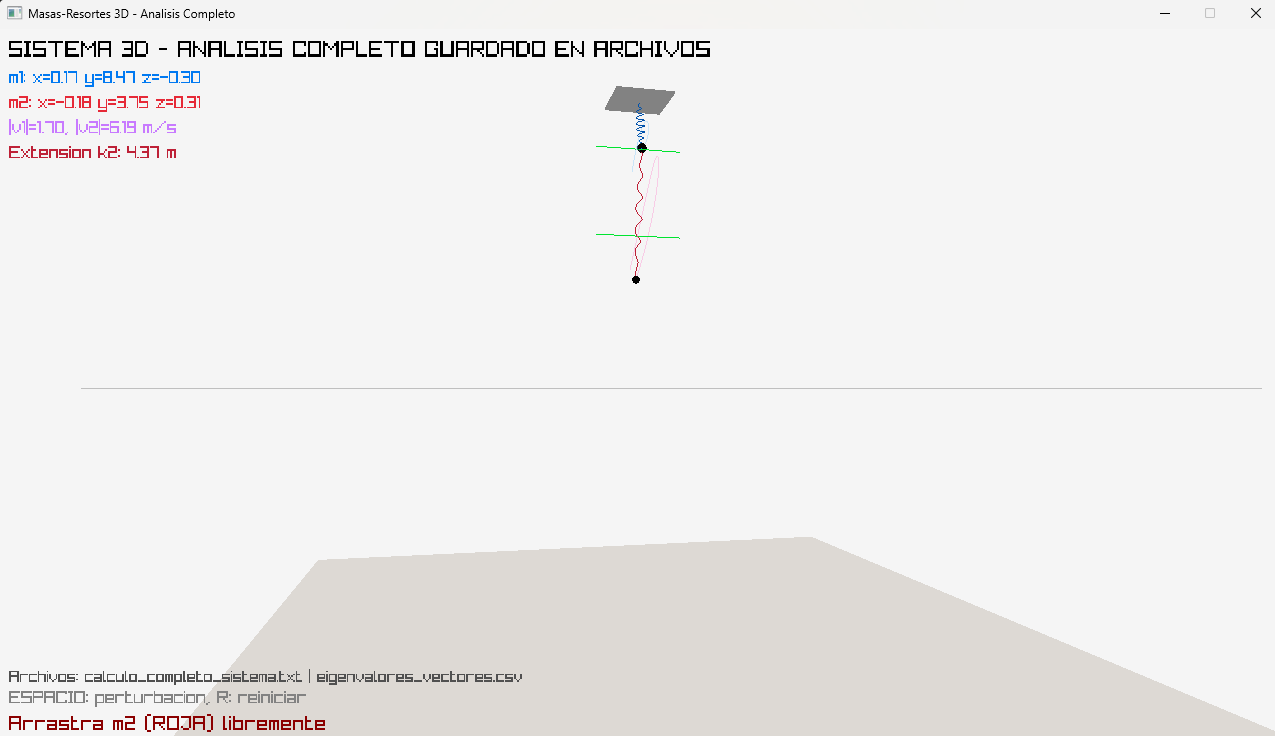
